#Removing punctuation

In [13]:
import pandas as pd
import numpy as np
import string

In [ ]:
df=pd.read_excel("/content/punctuation.xlsx")

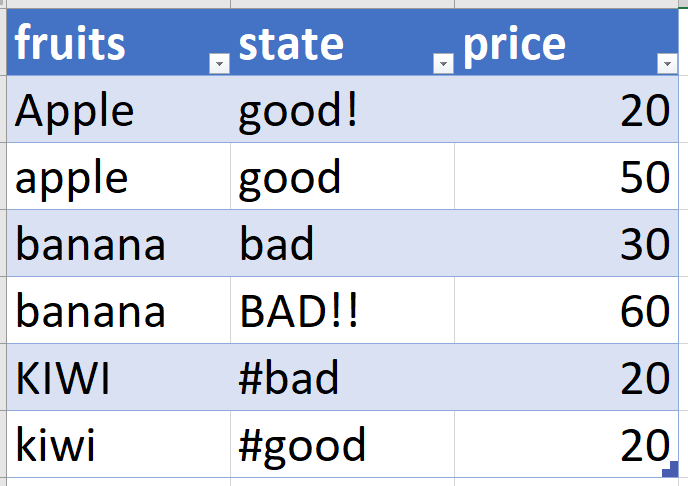

In [ ]:
df

,fruits,state,price
0,Apple,good!,20
1,apple,good,50
2,banana,bad,30
3,banana,BAD!!,60
4,KIWI,#bad,20
5,kiwi,#good,20


In [ ]:
p=string.punctuation
print(p)

!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~


In [ ]:
def reomve_punctation(cell):
  New_cell=""
  for char in cell:
    if char not in p:
      textcell=textcell+char
  return New_cell

In [ ]:
df['state']=df['state'].apply(reomve_punctation)
df

,fruits,state,price
0,Apple,good,20
1,apple,good,50
2,banana,bad,30
3,banana,BAD,60
4,KIWI,bad,20
5,kiwi,good,20


In [ ]:
df['fruits']=df['fruits'].str.lower()
df['state']=df['state'].str.lower()
df

,fruits,state,price
0,apple,good,20
1,apple,good,50
2,banana,bad,30
3,banana,bad,60
4,kiwi,bad,20
5,kiwi,good,20


In [ ]:
text_col=df.select_dtypes(include='object').columns
text_col

Index(['fruits', 'state'], dtype='object')

In [ ]:
for col in df[text_col]:
  df[col]=df[col].str.lower()

In [ ]:
df

,fruits,state,price
0,apple,good,20
1,apple,good,50
2,banana,bad,30
3,banana,bad,60
4,kiwi,bad,20
5,kiwi,good,20


#Remove StopWords

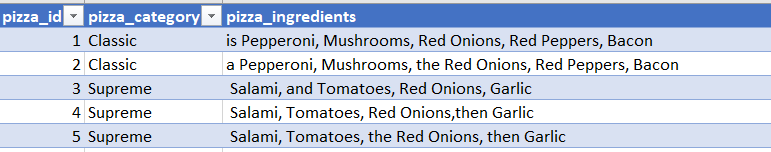

In [5]:
from nltk.corpus import stopwords

In [7]:
english_stopwords = stopwords.words('english')

In [8]:
english_stopwords

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [14]:
df=pd.read_excel("/content/stop_words.xlsx")

In [15]:
df

,pizza_id,pizza_category,pizza_ingredients
0,1,Classic,"is Pepperoni, Mushrooms, Red Onions, Red Peppe..."
1,2,Classic,"a Pepperoni, Mushrooms, the Red Onions, Red Pe..."
2,3,Supreme,"Salami, and Tomatoes, Red Onions, Garlic"
3,4,Supreme,"Salami, Tomatoes, Red Onions,then Garlic"
4,5,Supreme,"Salami, Tomatoes, the Red Onions, then Garlic"


In [ ]:
df['pizza_ingredients'].str.split()

,pizza_ingredients
0,"[is, Pepperoni,, Mushrooms,, Red, Onions,, Red..."
1,"[a, Pepperoni,, Mushrooms,, the, Red, Onions,,..."
2,"[Salami,, and, Tomatoes,, Red, Onions,, Garlic]"
3,"[Salami,, Tomatoes,, Red, Onions,then, Garlic]"
4,"[Salami,, Tomatoes,, the, Red, Onions,, then, ..."


In [20]:
def remove_stopWords(cell):
  words = cell.split()
  text=""
  for word in words:
    if word.lower() not in english_stopwords:
          text = text + word + " "
  return text




In [21]:
df['pizza_ingredients']=df['pizza_ingredients'].apply(remove_stopWords)
df

,pizza_id,pizza_category,pizza_ingredients
0,1,Classic,"Pepperoni,Mushrooms,RedOnions,RedPeppers,Bacon"
1,2,Classic,"Pepperoni,Mushrooms,RedOnions,RedPeppers,Bacon"
2,3,Supreme,"Salami,Tomatoes,RedOnions,Garlic"
3,4,Supreme,"Salami,Tomatoes,RedOnions,thenGarlic"
4,5,Supreme,"Salami,Tomatoes,RedOnions,Garlic"


In [ ]:
df['pizza_ingredients']

,pizza_ingredients
0,"Pepperoni, Mushrooms, Red Onions, Red Peppers,..."
1,"Pepperoni, Mushrooms, Red Onions, Red Peppers,..."
2,"Salami, Tomatoes, Red Onions, Garlic"
3,"Salami, Tomatoes, Red Onions,then Garlic"
4,"Salami, Tomatoes, Red Onions, Garlic"


In [22]:
df

,pizza_id,pizza_category,pizza_ingredients
0,1,Classic,"Pepperoni,Mushrooms,RedOnions,RedPeppers,Bacon"
1,2,Classic,"Pepperoni,Mushrooms,RedOnions,RedPeppers,Bacon"
2,3,Supreme,"Salami,Tomatoes,RedOnions,Garlic"
3,4,Supreme,"Salami,Tomatoes,RedOnions,thenGarlic"
4,5,Supreme,"Salami,Tomatoes,RedOnions,Garlic"
